<a href="https://colab.research.google.com/github/safaldev12/DOCUMENT/blob/main/BERT_Week7_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 Assignment – BERT: Theory, Architecture & Practical Example
Course: TECH 400 – Introduction to Information Retrieval  

In [1]:
# Cell 1: Install libraries
!pip install transformers datasets torch scikit-learn matplotlib seaborn --quiet
print("All libraries installed successfully!")

All libraries installed successfully!


In [2]:
# Cell 2: Import libraries
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    BertModel,
    BertConfig
)
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Libraries imported successfully!")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
import transformers
print(f"Transformers version: {transformers.__version__}")

Libraries imported successfully!
Device: cuda
PyTorch version: 2.10.0+cu128
Transformers version: 5.0.0


In [3]:
# Cell 3: BERT-Base Architecture Exploration
config = BertConfig()

print("=" * 55)
print("       BERT-Base Architecture Configuration")
print("=" * 55)
print(f"  Encoder Layers (L)            : {config.num_hidden_layers}")
print(f"  Hidden Size (H)               : {config.hidden_size}")
print(f"  Attention Heads (A)           : {config.num_attention_heads}")
print(f"  Intermediate (FFN) Size       : {config.intermediate_size}")
print(f"  Max Position Embeddings       : {config.max_position_embeddings}")
print(f"  Vocabulary Size               : {config.vocab_size}")
print(f"  Hidden Dropout                : {config.hidden_dropout_prob}")
print(f"  Attention Dropout             : {config.attention_probs_dropout_prob}")
print(f"  Type Vocab Size (Segments)    : {config.type_vocab_size}")
print("=" * 55)

embed_p = config.vocab_size * config.hidden_size
attn_p  = 4 * (config.hidden_size ** 2)
ffn_p   = 2 * config.hidden_size * config.intermediate_size
per_layer = attn_p + ffn_p
total = embed_p + config.num_hidden_layers * per_layer

print(f"  Approx Parameter Breakdown:")
print(f"    Token Embeddings  : {embed_p/1e6:.1f}M")
print(f"    Per Encoder Layer : {per_layer/1e6:.2f}M")
print(f"    All 12 Layers     : {config.num_hidden_layers*per_layer/1e6:.1f}M")
print(f"    Total (approx)    : ~{total/1e6:.0f}M parameters")
print("=" * 55)

       BERT-Base Architecture Configuration
  Encoder Layers (L)            : 12
  Hidden Size (H)               : 768
  Attention Heads (A)           : 12
  Intermediate (FFN) Size       : 3072
  Max Position Embeddings       : 512
  Vocabulary Size               : 30522
  Hidden Dropout                : 0.1
  Attention Dropout             : 0.1
  Type Vocab Size (Segments)    : 2
  Approx Parameter Breakdown:
    Token Embeddings  : 23.4M
    Per Encoder Layer : 7.08M
    All 12 Layers     : 84.9M
    Total (approx)    : ~108M parameters


In [4]:
# Cell 4: BERT WordPiece Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

sentences = [
    "BERT reads text bidirectionally.",
    "Natural Language Processing is fascinating!",
    "The patient was given medication after consultation."
]

print("=" * 62)
print("        BERT WordPiece Tokenization Examples")
print("=" * 62)
for sent in sentences:
    tokens = tokenizer.tokenize(sent)
    ids    = tokenizer.encode(sent, add_special_tokens=True)
    print(f"\n  Input    : {sent}")
    print(f"  Tokens   : {tokens}")
    print(f"  Token IDs: {ids}")
    print(f"  Length   : {len(ids)} tokens (incl. [CLS] and [SEP])")
    print("-" * 62)

print("\n  Special Token IDs:")
print(f"    [CLS]={tokenizer.cls_token_id}  [SEP]={tokenizer.sep_token_id}  [MASK]={tokenizer.mask_token_id}  [PAD]={tokenizer.pad_token_id}")

word = "bidirectionally"
subwords = tokenizer.tokenize(word)
print(f"\n  WordPiece: '{word}' -> {subwords}")
print("=" * 62)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

        BERT WordPiece Tokenization Examples

  Input    : BERT reads text bidirectionally.
  Tokens   : ['bert', 'reads', 'text', 'bid', '##ire', '##ction', '##ally', '.']
  Token IDs: [101, 14324, 9631, 3793, 7226, 7442, 7542, 3973, 1012, 102]
  Length   : 10 tokens (incl. [CLS] and [SEP])
--------------------------------------------------------------

  Input    : Natural Language Processing is fascinating!
  Tokens   : ['natural', 'language', 'processing', 'is', 'fascinating', '!']
  Token IDs: [101, 3019, 2653, 6364, 2003, 17160, 999, 102]
  Length   : 8 tokens (incl. [CLS] and [SEP])
--------------------------------------------------------------

  Input    : The patient was given medication after consultation.
  Tokens   : ['the', 'patient', 'was', 'given', 'medication', 'after', 'consultation', '.']
  Token IDs: [101, 1996, 5776, 2001, 2445, 14667, 2044, 16053, 1012, 102]
  Length   : 10 tokens (incl. [CLS] and [SEP])
------------------------------------------------------------

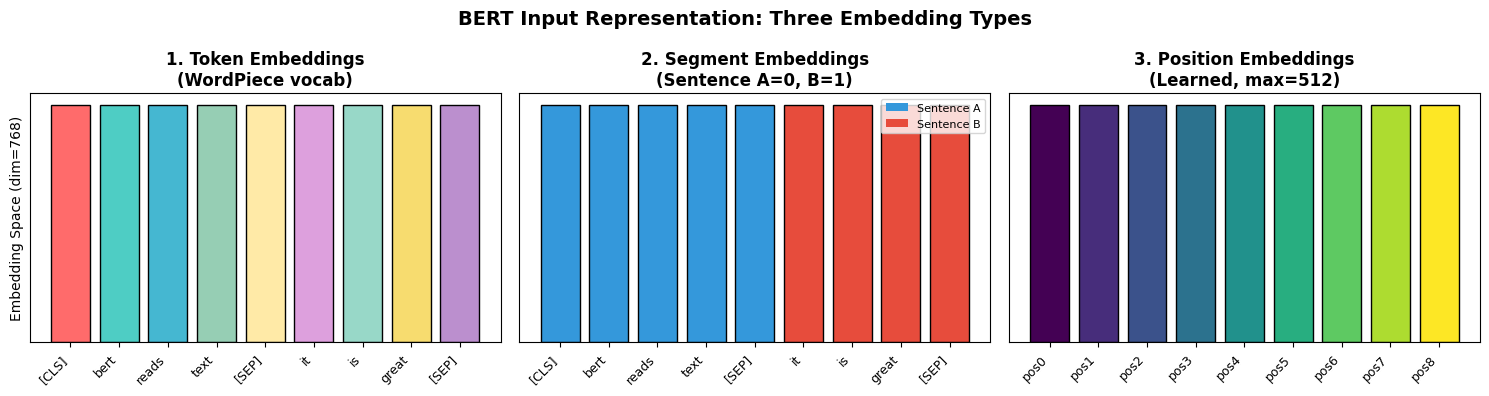

Final Input = Token Emb + Segment Emb + Position Emb  (element-wise sum)


In [5]:
# Cell 5: BERT Input Representation Visualization
from matplotlib.patches import Patch

tokens_list = ['[CLS]','bert','reads','text','[SEP]','it','is','great','[SEP]']
n = len(tokens_list)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("BERT Input Representation: Three Embedding Types", fontsize=14, fontweight="bold")

colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD','#98D8C8','#F7DC6F','#BB8FCE']

axes[0].bar(range(n), [1]*n, color=colors, edgecolor='black')
axes[0].set_xticks(range(n))
axes[0].set_xticklabels(tokens_list, rotation=45, ha='right', fontsize=9)
axes[0].set_title("1. Token Embeddings\n(WordPiece vocab)", fontweight="bold")
axes[0].set_ylabel("Embedding Space (dim=768)")
axes[0].set_yticks([])

seg_colors = ['#3498DB']*5 + ['#E74C3C']*4
axes[1].bar(range(n), [1]*n, color=seg_colors, edgecolor='black')
axes[1].set_xticks(range(n))
axes[1].set_xticklabels(tokens_list, rotation=45, ha='right', fontsize=9)
axes[1].set_title("2. Segment Embeddings\n(Sentence A=0, B=1)", fontweight="bold")
axes[1].set_yticks([])
legend_elements = [Patch(facecolor='#3498DB', label='Sentence A'), Patch(facecolor='#E74C3C', label='Sentence B')]
axes[1].legend(handles=legend_elements, fontsize=8)

cmap = plt.cm.get_cmap('viridis', n)
axes[2].bar(range(n), [1]*n, color=[cmap(i) for i in range(n)], edgecolor='black')
axes[2].set_xticks(range(n))
axes[2].set_xticklabels([f'pos{i}' for i in range(n)], rotation=45, ha='right', fontsize=9)
axes[2].set_title("3. Position Embeddings\n(Learned, max=512)", fontweight="bold")
axes[2].set_yticks([])

plt.tight_layout()
plt.savefig('bert_input_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final Input = Token Emb + Segment Emb + Position Emb  (element-wise sum)")

       Dataset Summary
  Total Samples    : 30
  Positive Reviews : 15 (label=1)
  Negative Reviews : 15 (label=0)
  Training Samples : 24
  Testing Samples  : 6


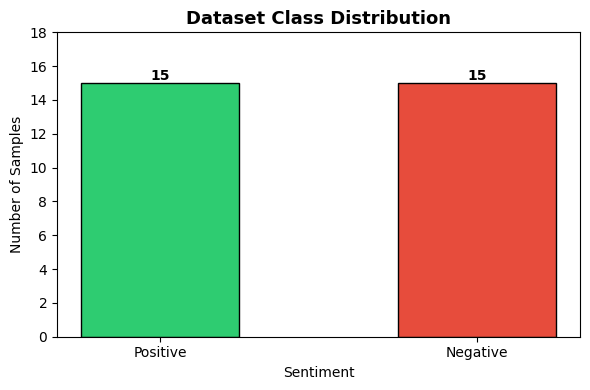

Dataset ready!


In [7]:
# Cell 6: Prepare Sentiment Dataset
texts = [
    "The doctor was very helpful and the consultation was smooth.",
    "Medicine was delivered quickly, great service!",
    "Excellent healthcare app, booked appointment in seconds.",
    "The video call with the doctor was crystal clear.",
    "QR code for the test was generated instantly, very convenient.",
    "I am very satisfied with the online consultation service.",
    "The pharmacy delivery was on time and the medicine was correct.",
    "Great experience using the telemedicine feature.",
    "The doctor explained the treatment clearly over video call.",
    "Booking a lab test was very easy with this app.",
    "The app made it simple to manage my grandfather's medications.",
    "Appointment reminder notification worked perfectly.",
    "Super fast and reliable healthcare platform.",
    "Loved the bilingual support in Nepali and English.",
    "Payment via eSewa was seamless and secure.",
    "The medicine delivery was delayed by three days.",
    "Doctor was not available despite confirmed appointment.",
    "The video call kept disconnecting during consultation.",
    "Very difficult to navigate the booking system.",
    "The app crashed when I tried to pay for the test.",
    "Waiting time for the doctor was too long.",
    "Wrong medicine was delivered to my address.",
    "The QR code for the appointment did not scan properly.",
    "Customer support was unresponsive to my complaint.",
    "The app is too slow and keeps showing errors.",
    "I could not connect to the server for video consultation.",
    "The prescription was illegible in the scanned copy.",
    "Terrible experience, the app logged me out repeatedly.",
    "Refund for cancelled appointment was not processed.",
    "Very poor user experience, needs major improvement.",
]
labels = [1]*15 + [0]*15

df = pd.DataFrame({'text': texts, 'label': labels,
                   'sentiment': ['Positive' if l==1 else 'Negative' for l in labels]})

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(),
    test_size=0.2, random_state=42, stratify=df['label'].tolist()
)

print("=" * 50)
print("       Dataset Summary")
print("=" * 50)
print(f"  Total Samples    : {len(df)}")
print(f"  Positive Reviews : 15 (label=1)")
print(f"  Negative Reviews : 15 (label=0)")
print(f"  Training Samples : {len(train_texts)}")
print(f"  Testing Samples  : {len(test_texts)}")
print("=" * 50)

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['sentiment'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ECC71','#E74C3C'], edgecolor='black', width=0.5)
ax.set_title("Dataset Class Distribution", fontweight="bold", fontsize=13)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Samples")
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, str(count), ha='center', fontweight='bold')
ax.set_ylim(0, 18)
plt.tight_layout()
plt.show()
print("Dataset ready!")

In [8]:
# Cell 7: Tokenize and Encode Dataset
MAX_LEN = 64
BATCH_SIZE = 8

def encode_texts(texts, labels, tokenizer, max_len):
    encoding = tokenizer(
        texts, max_length=max_len,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    return encoding['input_ids'], encoding['attention_mask'], torch.tensor(labels, dtype=torch.long)

train_ids, train_mask, train_lbl = encode_texts(train_texts, train_labels, tokenizer, MAX_LEN)
test_ids,  test_mask,  test_lbl  = encode_texts(test_texts,  test_labels,  tokenizer, MAX_LEN)

train_loader = DataLoader(TensorDataset(train_ids, train_mask, train_lbl), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_ids,  test_mask,  test_lbl),  batch_size=BATCH_SIZE, shuffle=False)

print("=" * 52)
print("       Tokenization and Encoding Complete")
print("=" * 52)
print(f"  Max Sequence Length : {MAX_LEN}")
print(f"  Train input shape   : {train_ids.shape}")
print(f"  Test  input shape   : {test_ids.shape}")
print(f"  Train batches       : {len(train_loader)}")
print(f"  Test  batches       : {len(test_loader)}")
print("\n  Sample (first row):")
print(f"  input_ids : {train_ids[0][:10].tolist()} ...")
print(f"  attn_mask : {train_mask[0][:10].tolist()} ...")
print(f"  label     : {train_lbl[0].item()}")
print("DataLoaders ready!")

       Tokenization and Encoding Complete
  Max Sequence Length : 64
  Train input shape   : torch.Size([24, 64])
  Test  input shape   : torch.Size([6, 64])
  Train batches       : 3
  Test  batches       : 1

  Sample (first row):
  input_ids : [101, 8013, 2490, 2001, 4895, 6072, 26029, 12742, 2000, 2026] ...
  attn_mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...
  label     : 0
DataLoaders ready!


In [9]:
# Cell 8: Load BERT for Sequence Classification
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print("  BERT for Sequence Classification Loaded")
print("=" * 50)
print(f"  Model            : bert-base-uncased")
print(f"  Num Labels       : 2 (Positive / Negative)")
print(f"  Total Parameters : {total_params:,}")
print(f"  Trainable Params : {trainable_params:,}")
print(f"  Device           : {device}")
print("\n  Top-level layers:")
for name, module in model.named_children():
    print(f"    [{name}] -> {type(module).__name__}")
print("\nModel ready!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  BERT for Sequence Classification Loaded
  Model            : bert-base-uncased
  Num Labels       : 2 (Positive / Negative)
  Total Parameters : 109,483,778
  Trainable Params : 109,483,778
  Device           : cuda

  Top-level layers:
    [bert] -> BertModel
    [dropout] -> Dropout
    [classifier] -> Linear

Model ready!


In [10]:
# Cell 9: Fine-Tune BERT
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS = 4
LR = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, eps=1e-8)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

train_losses, train_accuracies = [], []

print("=" * 52)
print("         BERT Fine-Tuning Started")
print("=" * 52)
print(f"  Epochs: {EPOCHS}  |  LR: {LR}  |  Optimizer: AdamW")
print("=" * 52)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    for batch in train_loader:
        ids, mask, lbl = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(input_ids=ids, attention_mask=mask, labels=lbl)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == lbl).sum().item()
        total   += lbl.size(0)
    avg_loss = epoch_loss / len(train_loader)
    acc = correct / total * 100
    train_losses.append(avg_loss)
    train_accuracies.append(acc)
    print(f"  Epoch [{epoch+1}/{EPOCHS}]  Loss: {avg_loss:.4f}  Accuracy: {acc:.2f}%")

print("Fine-tuning complete!")

         BERT Fine-Tuning Started
  Epochs: 4  |  LR: 2e-05  |  Optimizer: AdamW
  Epoch [1/4]  Loss: 0.7146  Accuracy: 50.00%
  Epoch [2/4]  Loss: 0.6837  Accuracy: 54.17%
  Epoch [3/4]  Loss: 0.6002  Accuracy: 62.50%
  Epoch [4/4]  Loss: 0.5938  Accuracy: 70.83%
Fine-tuning complete!


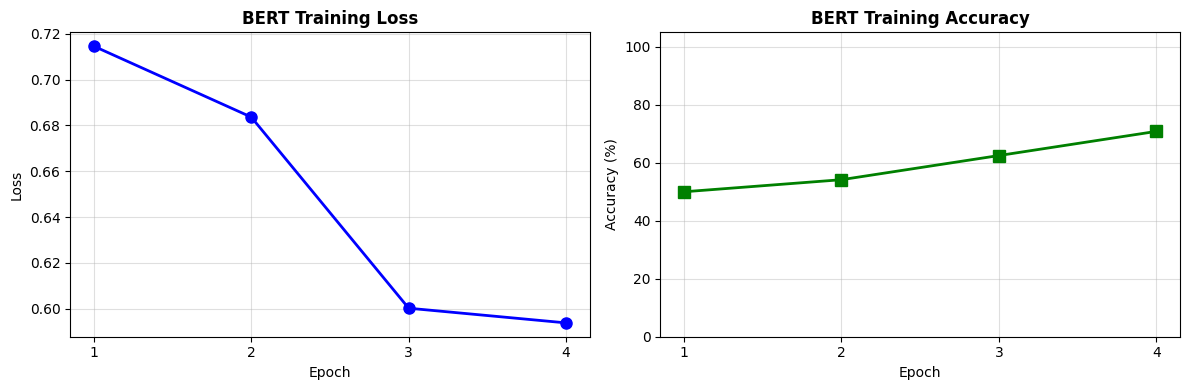

Training curves saved!


In [11]:
# Cell 10: Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS+1)

ax1.plot(epochs_range, train_losses, 'b-o', linewidth=2, markersize=8)
ax1.set_title("BERT Training Loss", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.4)
ax1.set_xticks(list(epochs_range))

ax2.plot(epochs_range, train_accuracies, 'g-s', linewidth=2, markersize=8)
ax2.set_title("BERT Training Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True, alpha=0.4)
ax2.set_xticks(list(epochs_range))
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved!")

  Test Accuracy: 50.00%

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67         3
    Positive       0.00      0.00      0.00         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



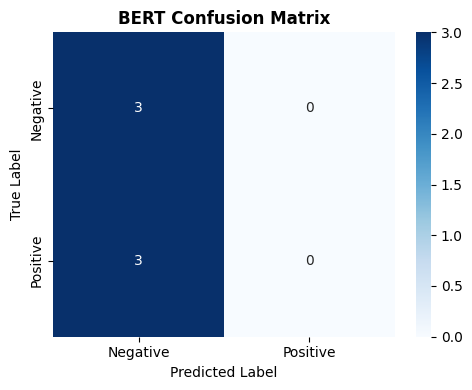

In [12]:
# Cell 11: Evaluate on Test Set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        ids, mask, lbl = [b.to(device) for b in batch]
        outputs = model(input_ids=ids, attention_mask=mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbl.cpu().numpy())

acc = accuracy_score(all_labels, all_preds) * 100
print("=" * 52)
print(f"  Test Accuracy: {acc:.2f}%")
print("\n  Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Negative','Positive']))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'], ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("BERT Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Cell 12: Inference on New Sentences
def predict_sentiment(texts, model, tokenizer, device, max_len=64):
    model.eval()
    enc = tokenizer(texts, max_length=max_len, padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        out = model(input_ids=enc['input_ids'].to(device), attention_mask=enc['attention_mask'].to(device))
    probs = torch.softmax(out.logits, dim=1).cpu().numpy()
    return np.argmax(probs, axis=1), probs

new_sentences = [
    "The online doctor appointment was very smooth and helpful.",
    "App crashed multiple times during the payment process.",
    "Medicine arrived quickly with proper packaging.",
    "Could not connect to the video call at all, very frustrating.",
    "Great experience, the QR ticket worked perfectly at the lab."
]

preds, probs = predict_sentiment(new_sentences, model, tokenizer, device)

print("=" * 65)
print("         BERT Sentiment Predictions")
print("=" * 65)
for i, (s, pred, prob) in enumerate(zip(new_sentences, preds, probs)):
    label = 'Positive' if pred==1 else 'Negative'
    conf  = prob[pred]*100
    print(f"{i+1}. [{label:8s} {conf:.1f}%] {s[:55]}")
print("=" * 65)

         BERT Sentiment Predictions
1. [Negative 51.4%] The online doctor appointment was very smooth and helpf
2. [Negative 65.9%] App crashed multiple times during the payment process.
3. [Positive 50.2%] Medicine arrived quickly with proper packaging.
4. [Negative 57.3%] Could not connect to the video call at all, very frustr
5. [Positive 51.1%] Great experience, the QR ticket worked perfectly at the


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


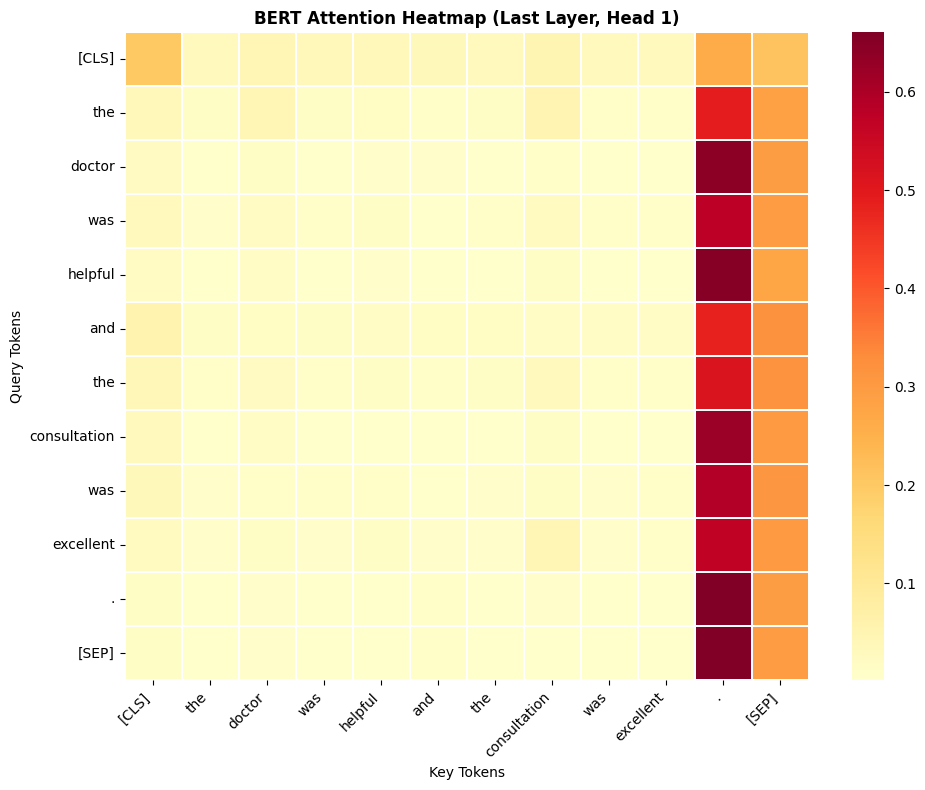

Brighter = stronger attention between token pairs


In [14]:
# Cell 13: Attention Visualization
bert_attn = BertModel.from_pretrained('bert-base-uncased', output_attentions=True).to(device)
bert_attn.eval()

sample = "The doctor was helpful and the consultation was excellent."
tokens_vis = ['[CLS]'] + tokenizer.tokenize(sample) + ['[SEP]']
inputs = tokenizer(sample, return_tensors='pt').to(device)

with torch.no_grad():
    out = bert_attn(**inputs)

attn = out.attentions[-1][0, 0].cpu().numpy()
slen = len(tokens_vis)
attn = attn[:slen, :slen]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(attn, xticklabels=tokens_vis, yticklabels=tokens_vis,
            cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_title("BERT Attention Heatmap (Last Layer, Head 1)", fontweight="bold")
ax.set_xlabel("Key Tokens")
ax.set_ylabel("Query Tokens")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bert_attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Brighter = stronger attention between token pairs")